In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(r"C:\Users\chira\Downloads\10.midcap_alpha_factors_unclean.csv")

Finding all the noise-data

In [3]:
# Null values = Close = 45 , Volume = 38

df.isnull().sum()

Date       0
Stock      0
Open       0
High       0
Low        0
Close     45
Volume    38
dtype: int64

In [4]:
# Duplicate Values  = 3

df.duplicated().sum()

3

In [5]:
# Checking datatype pf Date which is object

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6474 entries, 0 to 6473
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    6474 non-null   object 
 1   Stock   6474 non-null   object 
 2   Open    6474 non-null   float64
 3   High    6474 non-null   float64
 4   Low     6474 non-null   float64
 5   Close   6429 non-null   float64
 6   Volume  6436 non-null   float64
dtypes: float64(5), object(2)
memory usage: 354.2+ KB


Cleaning all the noise-data and filtering

In [6]:
# Eliminating Null values
df = df.dropna(subset = ["Close", "Volume"])

# Eliminating Duplicate values
df = df.drop_duplicates()

# Changing Date dtype
df["Date"] = pd.to_datetime(df["Date"])


In [7]:
print(df.isnull().sum(), "\n")

print(df.duplicated().sum(), "\n")

print(df.info(), "\n")

Date      0
Stock     0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64 

0 

<class 'pandas.core.frame.DataFrame'>
Index: 6388 entries, 0 to 6473
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    6388 non-null   datetime64[ns]
 1   Stock   6388 non-null   object        
 2   Open    6388 non-null   float64       
 3   High    6388 non-null   float64       
 4   Low     6388 non-null   float64       
 5   Close   6388 non-null   float64       
 6   Volume  6388 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 399.2+ KB
None 



###  Goal- Create a new alpha signal by combining:
 

1.  20-day Momentum = past performance

2.  20-day Volatility = risk measure

3.  Composite Score = Momentum / Volatility

In [8]:
# 1 Calculating Momentum (20-day % return)
df["Momentum_20d"] = df.groupby("Stock")["Close"].pct_change(periods = 20)

# 2 Calculating Volatility (20-day rolling std deviation)
df["Volatility_20d"] = df.groupby("Stock")["Close"].transform(lambda x : x.pct_change().rolling(window = 20).std())


#  Cleaning Null values from both
df = df.dropna(subset = ["Momentum_20d", "Volatility_20d"])

# 3 Creating Composite Alpha Score
df["Alpha_Score"] = df["Momentum_20d"] / df["Volatility_20d"]

Ranking Stocks Daily by Alpha Score

In [9]:
df["Alpha_Rank"] = df.groupby("Date")["Alpha_Score"].rank(ascending = False, method = "first")

In [10]:
#  Normalizing Rank to [0, 1] (for weighted strategies later)
df['Alpha_Weight'] = df['Alpha_Rank'] / df.groupby('Date')['Alpha_Rank'].transform('max')


# Composite Alpha Strategy Backtest 

# Goal:
    Long: Top 3 stocks by Alpha Score
    Short: Bottom 3 stocks
    Hold for 10 business days
    Rebalance every 10 days
    Track returns & cumulative PnL

In [11]:
results = []   #This is like an empty diary , We are using it to record what happened in each trade, (What date we entered
                #What date we exited, What stocks we longed and shorted, What profit or loss we made)


dates = sorted(df["Date"].unique())  # We need the daily trading dates, (Unique)

for i in range(20, len(dates) - 10, 10):  # Why ?  Trade many times to see if our strategy works overall,  Go step by step — every 10 trading days
                                           # Skip the first 20 days to allow space for past calculations (e.g., momentum or alpha scores)
                                           # Ensure we don’t go past the end (-10)
    date = dates[i]
    next_date = dates[i + 10]

    snapshot = df[df["Date"] == date].dropna(subset = ["Alpha_Score"])   # We keep only rows for that single date

    long_stocks = snapshot.sort_values("Alpha_Score").head(3)["Stock"]   # top 3 
    short_stocks = snapshot.sort_values("Alpha_Score").tail(3)["Stock"]  # bottom 3

    entry_prices = df[
        (df["Date"] == date) & 
        (df["Stock"].isin(long_stocks.tolist() + short_stocks.tolist()))]

    exit_prices = df[
        (df["Date"] == next_date) &
        (df["Stock"].isin(long_stocks.tolist() + short_stocks.tolist()))]

    merged = pd.merge(
        entry_prices[["Stock", "Close"]],
        exit_prices[["Stock", "Close"]],
        on = "Stock",
        suffixes = ("_entry", "_exit")
    )

# Assigning direction , +1 for Long, -1 for Short
    merged["Direction"] = merged["Stock"].apply(lambda x : 1 if x in long_stocks.values else -1)

    merged["Return"] = merged["Direction"] * (merged["Close_exit"] - merged["Close_entry"]) / merged["Close_entry"]
    
    results.append({
        'Date': date,
        'Next_Date': next_date,
        'Strategy_Return': merged['Return'].mean(),
        'Long_Stocks': ', '.join(long_stocks.values),
        'Short_Stocks': ', '.join(short_stocks.values)
    })

strategy_composite_df = pd.DataFrame(results)
strategy_composite_df['Cumulative_Return'] = (1 + strategy_composite_df['Strategy_Return']).cumprod()

Plotting Cumulative Strategy Return

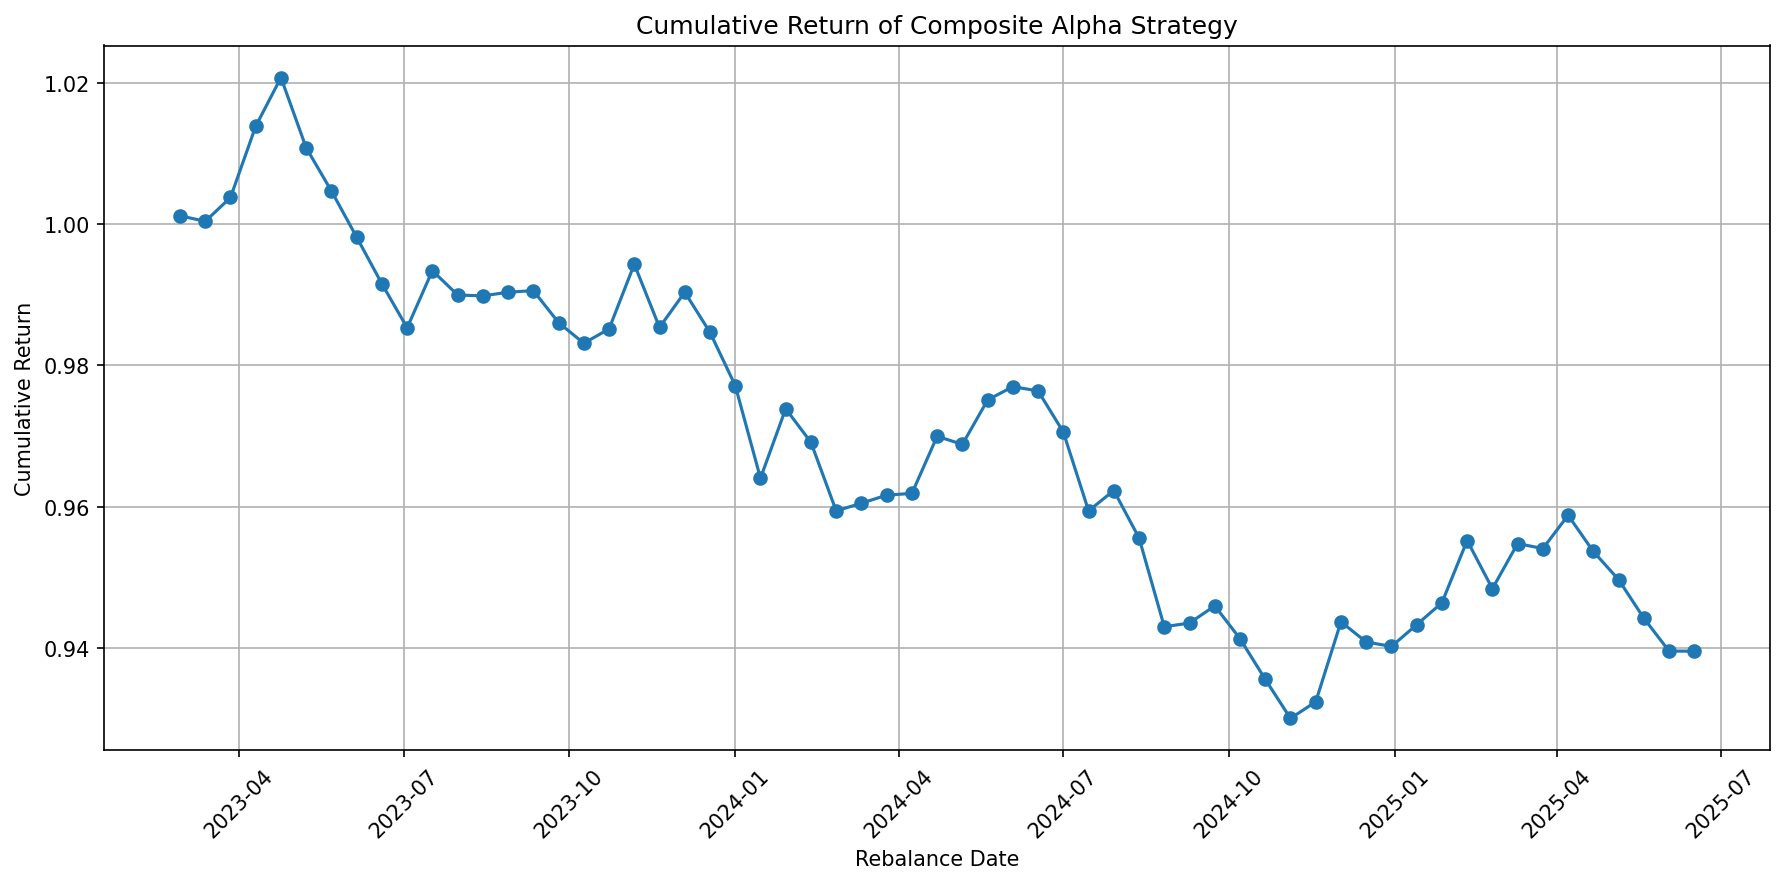

In [14]:


plt.figure(figsize=(12, 6), dpi = 150)
plt.plot(strategy_composite_df['Date'], strategy_composite_df['Cumulative_Return'], marker='o')
plt.title("Cumulative Return of Composite Alpha Strategy")
plt.xlabel("Rebalance Date")
plt.ylabel("Cumulative Return")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("10.composite_alpha_strategy.png", dpi=300)
plt.show()


In [15]:
strategy_composite_df.to_csv("10.composite_alpha_strategy.csv", index=False)